# Laboratorio 1 IA
## Mollinedo Siles Renzo Sebastian

Importamos librerias y descargamos el dataset.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Configuración de gráficas
%matplotlib inline

# Descarga del dataset
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
df_raw = pd.read_csv(os.path.join(path, 'dataset.csv'))

# Limpieza inicial: Eliminamos nulos, columnas innecesarias y canciones con 0 popuolaridad
df = df_raw.dropna().copy()
df = df.drop(columns=['Unnamed: 0']) # Índice duplicado
df = df[df['popularity'] > 0]

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.


DESCRIPCION DEL DATA SET

Este es un conjunto de datos de pistas de Spotify de 125 géneros diferentes. Cada pista tiene características de audio asociadas. Los datos están en formato CSV, que es tabular y se carga rápidamente.


In [ ]:
print(path)

#Vemos el contenido del dataset
print(os.listdir(path))

#Tomamos los primeros 50 valores
data = pd.read_csv(os.path.join(path,'dataset.csv'))
data.head(50)

/kaggle/input/-spotify-tracks-dataset
['dataset.csv']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


###Seleccionamos los features que son de nuestro interés

En esta ocasión entrenaremos un modelo que logre predecir que tan popular es una canción en base a los featueres elegidos.

In [ ]:
features = ["danceability", "energy", "loudness", "speechiness", "acousticness",
            "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]
target = "popularity"

Dividiremos los datos en Entrenamiento (80%) y Prueba (20%).

In [ ]:
df_shuffled = df.sample(frac=1, random_state=42)
split_index = int(0.8 * len(df_shuffled))

train_data = df_shuffled.iloc[:split_index]
test_data = df_shuffled.iloc[split_index:]

Seleccionamos X e Y

In [ ]:
X_train = train_data[features].values
y_train = train_data[target].values.reshape(-1, 1)

X_test = test_data[features].values
y_test = test_data[target].values.reshape(-1, 1)

**REGRESIÓN LINEAL MULTIVARIABLE**

In [ ]:
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
y_mean, y_std = y_train.mean(), y_train.std()

X_train_norm = (X_train - X_mean) / X_std
y_train_norm = (y_train - y_mean) / y_std

# Aplicamos los mismos parámetros al set de prueba
X_test_norm = (X_test - X_mean) / X_std

# Agregamos la columna de unos para el intercepto (Bias)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

In [ ]:
def calcularCosto(X, y, theta):
    m = y.size
    J = (1 / (2 * m)) * np.sum(np.square(X @ theta - y))
    return J

def gradientDescent(X, y, theta, alpha, num_iters, tol=1e-7):
    m = y.size
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        # Actualización simultánea de theta
        error = X @ theta - y
        theta -= (alpha / m) * (X.T @ error)

        costo = calcularCosto(X, y, theta)
        J_history.append(costo)

        # Criterio de parada temprana si el costo no mejora significativamente
        if i > 0 and abs(J_history[-2] - J_history[-1]) < tol:
            print(f"Convergencia alcanzada en la iteración {i}.")
            break

    return theta, J_history

**ENTRENAMIENTO**

Convergencia alcanzada en la iteración 208.


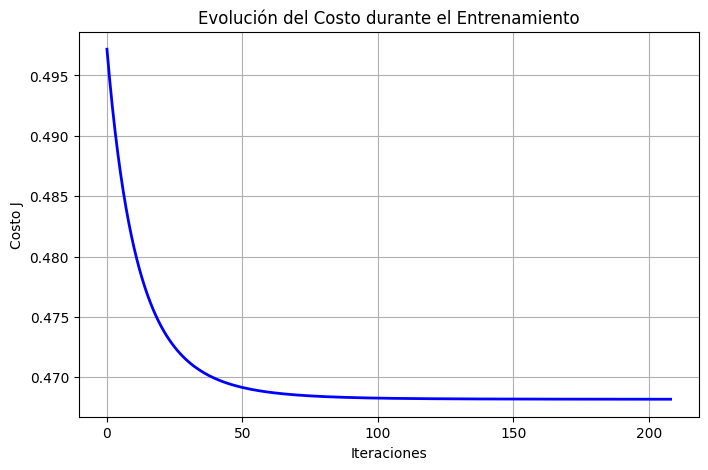

In [ ]:
theta_init = np.zeros((X_train_norm.shape[1], 1))
alpha = 0.05
iterations = 5000

theta_final, J_history = gradientDescent(X_train_norm, y_train_norm, theta_init, alpha, iterations)

# Visualización del costo
plt.figure(figsize=(8, 5))
plt.plot(J_history, color='blue', linewidth=2)
plt.title("Evolución del Costo durante el Entrenamiento")
plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.grid(True)
plt.show()

**PRUEBAS**

Tomamos 100 ejemplos del DATASET

In [ ]:
# 1. Realizar predicción en el set de prueba (X_test_norm)
y_pred_norm = X_test_norm @ theta_final

# 2. Desnormalizar para obtener valores de popularidad reales (0-100)
y_pred_final = (y_pred_norm * y_std) + y_mean

# 3. Métricas de Error
mae = np.mean(np.abs(y_test - y_pred_final))
print(f"Error Medio Absoluto (MAE): {mae:.2f} puntos de popularidad")

# 4. Comparación visual de los primeros 10 resultados
resultados = pd.DataFrame({
    'Real': y_test.flatten()[:10],
    'Predicho': y_pred_final.flatten()[:10],
    'Diferencia': np.abs(y_test.flatten()[:10] - y_pred_final.flatten()[:10])
})
print("\n--- Muestra de Predicciones ---")
print(resultados)

Error Medio Absoluto (MAE): 15.20 puntos de popularidad

--- Muestra de Predicciones ---
   Real   Predicho  Diferencia
0     9  33.585925   24.585925
1    35  37.038807    2.038807
2     3  40.214784   37.214784
3    74  37.402884   36.597116
4    38  40.929419    2.929419
5    16  38.945399   22.945399
6    58  39.723857   18.276143
7    70  43.660986   26.339014
8    33  43.283809   10.283809
9    45  36.987285    8.012715
